# **Introduction to ReInforcement Learning**

## **Project:** Model Setup & Training
## **Group Members:** Samiya Ali Zaidi, Javeria Azfar, Huzaifah Tariq Ahmed
## Double DQN Implementation

This particular notebook goes through the process of implementing `Double DQN`.

The Implementation is evaluted on three environments:

- Cart-Pole-V1
- Lunar-Lander-V3
- Frozen-Lake-V1

We evaluate the performance of the Network on following metrics:

- Train & Val Loss
- Sample Efficiency
- Over-Estimation Bias
- Stability

### **Install Dependencies**

In [ ]:
# HIDE OUTPUT
!apt-get update > /dev/null 2>&1
!apt-get install cmake > /dev/null 2>&1
!pip install --upgrade setuptools 2>&1
!pip install ez_setup > /dev/null 2>&1
!pip install gym[atari] > /dev/null 2>&1
!pip install gymnasium moviepy pyglet
# HIDE OUTPUT
!pip install gym pyvirtualdisplay > /dev/null 2>&1
!apt-get install -y xvfb python-opengl ffmpeg > /dev/null 2>&1
!sudo apt-get install xvfb
!pip install xvfbwrapper
!pip install gymnasium
!pip install swig
!pip install "gymnasium[box2d]"

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
xvfb is already the newest version (2:21.1.4-2ubuntu1.7~22.04.14).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.


### **Import Libraries**

In [ ]:
%matplotlib inline
import gym
import gymnasium as gym
import numpy as np
from gym.wrappers.record_video import RecordVideo
import glob
import io
import base64
from pyvirtualdisplay import Display
from IPython import display as ipythondisplay
from matplotlib import pyplot as plt
from IPython.display import HTML, display
from scipy.integrate import quad
from collections import defaultdict
import pygame
import os
import time
from moviepy.editor import ImageSequenceClip
import random
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import Box2D

# **Double DQN Implementation**

#### **Network Definition**

In [ ]:
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super(QNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim)
        )

    def forward(self, x):
        return self.net(x)

#### **Replay Buffer**

In [ ]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (np.array(states), np.array(actions), np.array(rewards, dtype=np.float32),
                np.array(next_states), np.array(dones, dtype=np.uint8))

    def __len__(self):
        return len(self.buffer)

#### **Double DQN Agent**

In [ ]:
class DoubleDQNAgent:
    def __init__(self, state_dim, action_dim,
                 buffer_capacity=50000, batch_size=64,
                 gamma=0.99, lr=1e-3, tau=1e-3,
                 epsilon_start=1.0, epsilon_end=0.01, epsilon_decay=10000):
        self.action_dim = action_dim
        self.batch_size = batch_size
        self.gamma = gamma
        self.tau = tau

        self.q_net = QNetwork(state_dim, action_dim)
        self.target_net = QNetwork(state_dim, action_dim)
        self.target_net.load_state_dict(self.q_net.state_dict())

        self.optimizer = optim.Adam(self.q_net.parameters(), lr=lr)
        self.replay_buffer = ReplayBuffer(buffer_capacity)

        self.epsilon_start = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay
        self.steps_done = 0

    def select_action(self, state):
        self.steps_done += 1
        eps = self.epsilon_end + (self.epsilon_start - self.epsilon_end) * \
              np.exp(-1. * self.steps_done / self.epsilon_decay)
        if random.random() < eps:
            return random.randrange(self.action_dim)
        else:
            with torch.no_grad():
                state_v = torch.FloatTensor(state).unsqueeze(0)
                return self.q_net(state_v).argmax().item()

    def update(self):
        if len(self.replay_buffer) < self.batch_size:
            return None, None

        states, actions, rewards, next_states, dones = self.replay_buffer.sample(self.batch_size)
        states_v = torch.FloatTensor(states)
        actions_v = torch.LongTensor(actions).unsqueeze(1)
        rewards_v = torch.FloatTensor(rewards).unsqueeze(1)
        next_states_v = torch.FloatTensor(next_states)
        dones_v = torch.FloatTensor(dones).unsqueeze(1)

        q_values = self.q_net(states_v).gather(1, actions_v)

        next_actions = self.q_net(next_states_v).argmax(dim=1, keepdim=True)
        next_q_target = self.target_net(next_states_v).gather(1, next_actions)
        q_target = rewards_v + self.gamma * next_q_target * (1 - dones_v)

        loss = nn.MSELoss()(q_values, q_target.detach())
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        for t_param, param in zip(self.target_net.parameters(), self.q_net.parameters()):
            t_param.data.copy_(self.tau * param.data + (1.0 - self.tau) * t_param.data)

        with torch.no_grad():
            max_q = self.q_net(states_v).max(1)[0].mean().item()
        return loss.item(), max_q

#### **Training Function**

In [ ]:
def train(agent, env, num_episodes=1000):
    rewards_hist, train_loss_hist, val_loss_hist, maxq_hist = [], [], [], []
    sns.set()

    for ep in range(1, num_episodes + 1):
        state, _ = env.reset()
        total_reward = 0
        ep_losses = []
        done = False

        while not done:
            action = agent.select_action(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            agent.replay_buffer.push(state, action, reward, next_state, done)
            state = next_state
            total_reward += reward

            loss, max_q = agent.update()
            if loss is not None:
                ep_losses.append(loss)
                maxq_hist.append(max_q)

        rewards_hist.append(total_reward)
        train_loss_hist.append(np.mean(ep_losses) if ep_losses else np.nan)

        # validation step
        if len(agent.replay_buffer) >= agent.batch_size:
            states, actions, rewards, next_states, dones = agent.replay_buffer.sample(agent.batch_size)
            with torch.no_grad():
                sv = torch.FloatTensor(states)
                av = torch.LongTensor(actions).unsqueeze(1)
                rv = torch.FloatTensor(rewards).unsqueeze(1)
                nsv = torch.FloatTensor(next_states)
                dv = torch.FloatTensor(dones).unsqueeze(1)

                qv = agent.q_net(sv).gather(1, av)
                na = agent.q_net(nsv).argmax(dim=1, keepdim=True)
                nq = agent.target_net(nsv).gather(1, na)
                tgt = rv + agent.gamma * nq * (1 - dv)
                val_loss = nn.MSELoss()(qv, tgt)
            val_loss_hist.append(val_loss.item())
        else:
            val_loss_hist.append(np.nan)

        if ep % 100 == 0:
            print(f"Ep {ep}/{num_episodes}: R={total_reward:.2f}, TrainL={train_loss_hist[-1]:.4f}, ValL={val_loss_hist[-1]:.4f}")

    return rewards_hist, train_loss_hist, val_loss_hist, maxq_hist

## **Running on Cart-Pole-V1 Environment**

Ep 100/500: R=15.00, TrainL=0.0243, ValL=0.0100
Ep 200/500: R=25.00, TrainL=0.0276, ValL=0.0454
Ep 300/500: R=112.00, TrainL=0.1103, ValL=0.4888
Ep 400/500: R=208.00, TrainL=0.4110, ValL=3.7534


  auc_reward = np.trapz(rewards)



Ep 500/500: R=109.00, TrainL=0.4138, ValL=0.1635
Sample Efficiency (AUC normalized): 37.96%
Average Reward: 76.05, Std: 80.23, CV: 1.05
Mean Max Q-value: 16.31

Train/Val Losses Over Epochs:
   Episode  Train Loss  Val Loss
0        1         NaN       NaN
1        2         NaN       NaN
2        3         NaN       NaN
3        4         NaN       NaN
4        5    0.737134  0.209652
     Episode  Train Loss  Val Loss
495      496    0.624843  0.202969
496      497    0.549615  0.343672
497      498    0.808653  0.274002
498      499    0.628804  0.130499
499      500    0.413788  0.163483


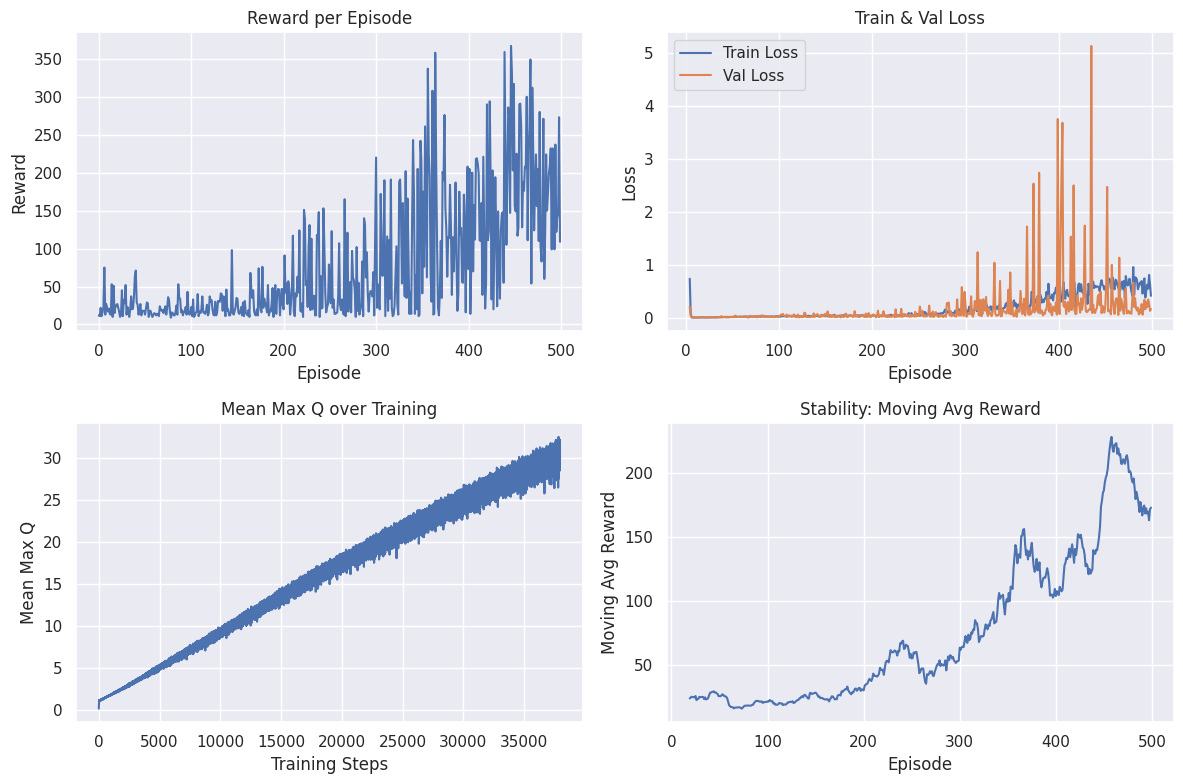

In [ ]:
if __name__ == '__main__':
    # Environment
    env = gym.make("CartPole-v1", render_mode="rgb_array")
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n
    agent = DoubleDQNAgent(state_dim, action_dim)

    # Train
    episodes = 500
    rewards, train_losses, val_losses, maxqs = train(agent, env, num_episodes=episodes)

    max_per_episode = 200 # max reward per episode

    # Quantitative Metrics
    auc_reward = np.trapz(rewards)
    mean_reward = np.mean(rewards)
    std_reward = np.std(rewards)
    cv_reward = std_reward / mean_reward # Coefficient of Variation (CV): std deviation divided by mean, measures relative variability
    mean_maxq = np.mean(maxqs)

    sample_efficiency_pct = (auc_reward / (max_per_episode * episodes)) * 100

    print(f"Sample Efficiency (AUC normalized): {sample_efficiency_pct:.2f}%")
    print(f"Average Reward: {mean_reward:.2f}, Std: {std_reward:.2f}, CV: {cv_reward:.2f}")
    print(f"Mean Max Q-value: {mean_maxq:.2f}")

    # Track losses over epochs
    df_losses = pd.DataFrame({
        'Episode': np.arange(1, episodes+1),
        'Train Loss': train_losses,
        'Val Loss': val_losses
    })
    df_losses.to_csv('losses_over_epochs.csv', index=False)
    # print first and last few rows for quick view
    print("\nTrain/Val Losses Over Epochs:")
    print(df_losses.head())
    print(df_losses.tail())

    # Plot all metrics in a 2x2 grid
    fig, axs = plt.subplots(2, 2, figsize=(12, 8))

    # Sample Efficiency (Reward per Episode)
    axs[0, 0].plot(rewards)
    axs[0, 0].set_title('Reward per Episode')
    axs[0, 0].set_xlabel('Episode')
    axs[0, 0].set_ylabel('Reward')

    # Loss Curves
    axs[0, 1].plot(train_losses, label='Train Loss')
    axs[0, 1].plot(val_losses, label='Val Loss')
    axs[0, 1].set_title('Train & Val Loss')
    axs[0, 1].set_xlabel('Episode')
    axs[0, 1].set_ylabel('Loss')
    axs[0, 1].legend()

    # Over-estimation Bias (Mean Max Q)
    axs[1, 0].plot(maxqs)
    axs[1, 0].set_title('Mean Max Q over Training')
    axs[1, 0].set_xlabel('Training Steps')
    axs[1, 0].set_ylabel('Mean Max Q')

    # Stability (Moving Avg Reward)
    window = 20
    mov_avg = np.convolve(rewards, np.ones(window)/window, mode='valid')
    axs[1, 1].plot(range(window-1, episodes), mov_avg)
    axs[1, 1].set_title('Stability: Moving Avg Reward')
    axs[1, 1].set_xlabel('Episode')
    axs[1, 1].set_ylabel('Moving Avg Reward')

    fig.tight_layout()
    plt.show()

    # Evaluation and Video Recording
    eval_frames = []
    obs, _ = env.reset()
    done = False
    while not done:
        action = agent.q_net(torch.FloatTensor(obs).unsqueeze(0)).argmax().item()
        obs, _, terminated, truncated, _ = env.step(action)
        eval_frames.append(env.render())
        done = terminated or truncated

    env.close()

    os.makedirs("video_ddqn", exist_ok=True)
    clip = ImageSequenceClip(eval_frames, fps=30)
    video_path = "video_ddqn/cartpole_ddqn_eval.mp4"
    clip.write_videofile(video_path, codec="libx264", verbose=False, logger=None)

    # Display Video in Notebook
    video_data = open(video_path, "rb").read()
    b64 = base64.b64encode(video_data).decode('ascii')
    display(HTML(f"""
    <video width=480 controls>
      <source src="data:video/mp4;base64,{b64}" type="video/mp4">
    </video>
    """))

## **Running on Lunar-Lander-V3 Environment**

Ep 100/500: R=18.53, TrainL=12.1227, ValL=19.5883
Ep 200/500: R=-24.40, TrainL=3.6902, ValL=1.1272
Ep 300/500: R=130.46, TrainL=9.1015, ValL=2.0008
Ep 400/500: R=-4.90, TrainL=15.7026, ValL=1.9842


  auc_reward = np.trapz(rewards)



Ep 500/500: R=265.06, TrainL=15.2080, ValL=8.3560
Sample Efficiency (AUC normalized): 3.02%
Average Reward: 9.21, Std: 176.44, CV: 19.16
Mean Max Q-value: 19.93

Train/Val Losses Over Epochs:
   Episode  Train Loss    Val Loss
0        1    6.099245  156.529572
1        2   42.383996  170.508316
2        3   51.636019    1.576443
3        4   52.975382    2.692363
4        5   32.387437   48.565498
     Episode  Train Loss    Val Loss
495      496   13.733617  378.511719
496      497   18.815036    1.940786
497      498   20.896285   17.293266
498      499   16.842191   22.485085
499      500   15.208045    8.356041


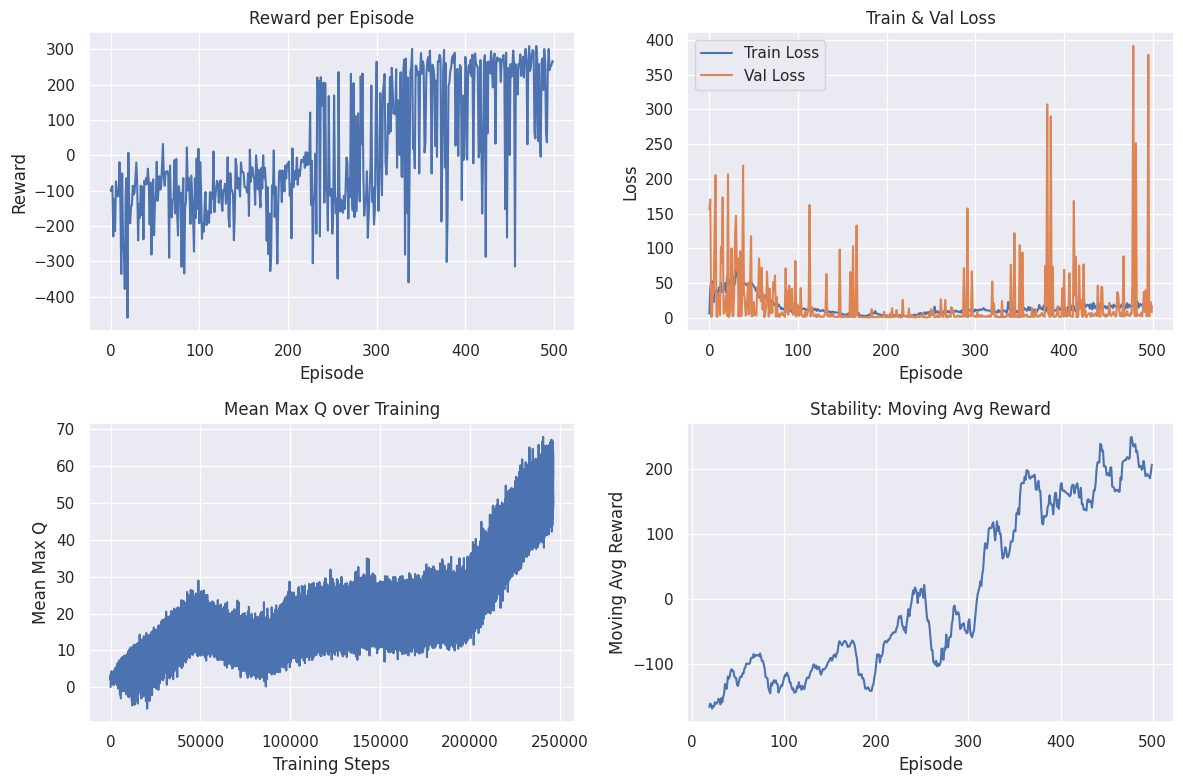

In [ ]:
if __name__ == '__main__':
    # Use LunarLander-v3 environment
    env = gym.make("LunarLander-v3", render_mode="rgb_array")
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n
    agent = DoubleDQNAgent(state_dim, action_dim)

    # Train
    episodes = 500
    rewards, train_losses, val_losses, maxqs = train(agent, env, num_episodes=episodes)

    max_per_episode = 300 # max reward per episode

    # Quantitative Metrics
    auc_reward = np.trapz(rewards)
    mean_reward = np.mean(rewards)
    std_reward = np.std(rewards)
    cv_reward = std_reward / mean_reward # Coefficient of Variation (CV): std deviation divided by mean, measures relative variability
    mean_maxq = np.mean(maxqs)

    sample_efficiency_pct = (auc_reward / (max_per_episode * episodes)) * 100

    print(f"Sample Efficiency (AUC normalized): {sample_efficiency_pct:.2f}%")
    print(f"Average Reward: {mean_reward:.2f}, Std: {std_reward:.2f}, CV: {cv_reward:.2f}")
    print(f"Mean Max Q-value: {mean_maxq:.2f}")

    # Track losses over epochs
    df_losses = pd.DataFrame({
        'Episode': np.arange(1, episodes+1),
        'Train Loss': train_losses,
        'Val Loss': val_losses
    })
    df_losses.to_csv('losses_over_epochs.csv', index=False)
    # print first and last few rows for quick view
    print("\nTrain/Val Losses Over Epochs:")
    print(df_losses.head())
    print(df_losses.tail())

    # Plot all metrics in a 2x2 grid
    fig, axs = plt.subplots(2, 2, figsize=(12, 8))

    # Sample Efficiency (Reward per Episode)
    axs[0, 0].plot(rewards)
    axs[0, 0].set_title('Reward per Episode')
    axs[0, 0].set_xlabel('Episode')
    axs[0, 0].set_ylabel('Reward')

    # Loss Curves
    axs[0, 1].plot(train_losses, label='Train Loss')
    axs[0, 1].plot(val_losses, label='Val Loss')
    axs[0, 1].set_title('Train & Val Loss')
    axs[0, 1].set_xlabel('Episode')
    axs[0, 1].set_ylabel('Loss')
    axs[0, 1].legend()

    # Over-estimation Bias (Mean Max Q)
    axs[1, 0].plot(maxqs)
    axs[1, 0].set_title('Mean Max Q over Training')
    axs[1, 0].set_xlabel('Training Steps')
    axs[1, 0].set_ylabel('Mean Max Q')

    # Stability (Moving Avg Reward)
    window = 20
    mov_avg = np.convolve(rewards, np.ones(window)/window, mode='valid')
    axs[1, 1].plot(range(window-1, episodes), mov_avg)
    axs[1, 1].set_title('Stability: Moving Avg Reward')
    axs[1, 1].set_xlabel('Episode')
    axs[1, 1].set_ylabel('Moving Avg Reward')

    fig.tight_layout()
    plt.show()

    # Evaluation Video
    eval_frames = []
    obs, _ = env.reset()
    done = False
    while not done:
        action = agent.q_net(torch.FloatTensor(obs).unsqueeze(0)).argmax().item()
        obs, _, terminated, truncated, _ = env.step(action)
        eval_frames.append(env.render())
        done = terminated or truncated

    env.close()
    os.makedirs("video_ddqn_ll", exist_ok=True)
    clip = ImageSequenceClip(eval_frames, fps=30)
    video_path = "video_ddqn_ll/lunarlander_ddqn_eval.mp4"
    clip.write_videofile(video_path, codec="libx264", verbose=False, logger=None)

    # Display Video
    video_data = open(video_path, "rb").read()
    b64 = base64.b64encode(video_data).decode('ascii')
    display(HTML(f"""
    <video width=480 controls>
      <source src="data:video/mp4;base64,{b64}" type="video/mp4">
    </video>
    """))

## **Running on Frozen-Lake-V1 Environment**

Ep 100/500: R=0.00, TrainL=0.0100, ValL=0.0111
Ep 200/500: R=0.00, TrainL=0.0098, ValL=0.0100
Ep 300/500: R=0.00, TrainL=0.0099, ValL=0.0033
Ep 400/500: R=1.00, TrainL=0.0101, ValL=0.0081


  auc_reward = np.trapz(rewards)



Ep 500/500: R=1.00, TrainL=0.0062, ValL=0.0021
Sample Efficiency (AUC normalized): 39.50%
Average Reward: 0.40, Std: 0.49, CV: 1.24
Mean Max Q-value: 0.37

Train/Val Losses Over Epochs:
   Episode  Train Loss  Val Loss
0        1         NaN       NaN
1        2         NaN       NaN
2        3         NaN       NaN
3        4         NaN       NaN
4        5         NaN       NaN
     Episode  Train Loss  Val Loss
495      496    0.006014  0.023831
496      497    0.004766  0.008617
497      498    0.005894  0.002983
498      499    0.005324  0.006418
499      500    0.006179  0.002132


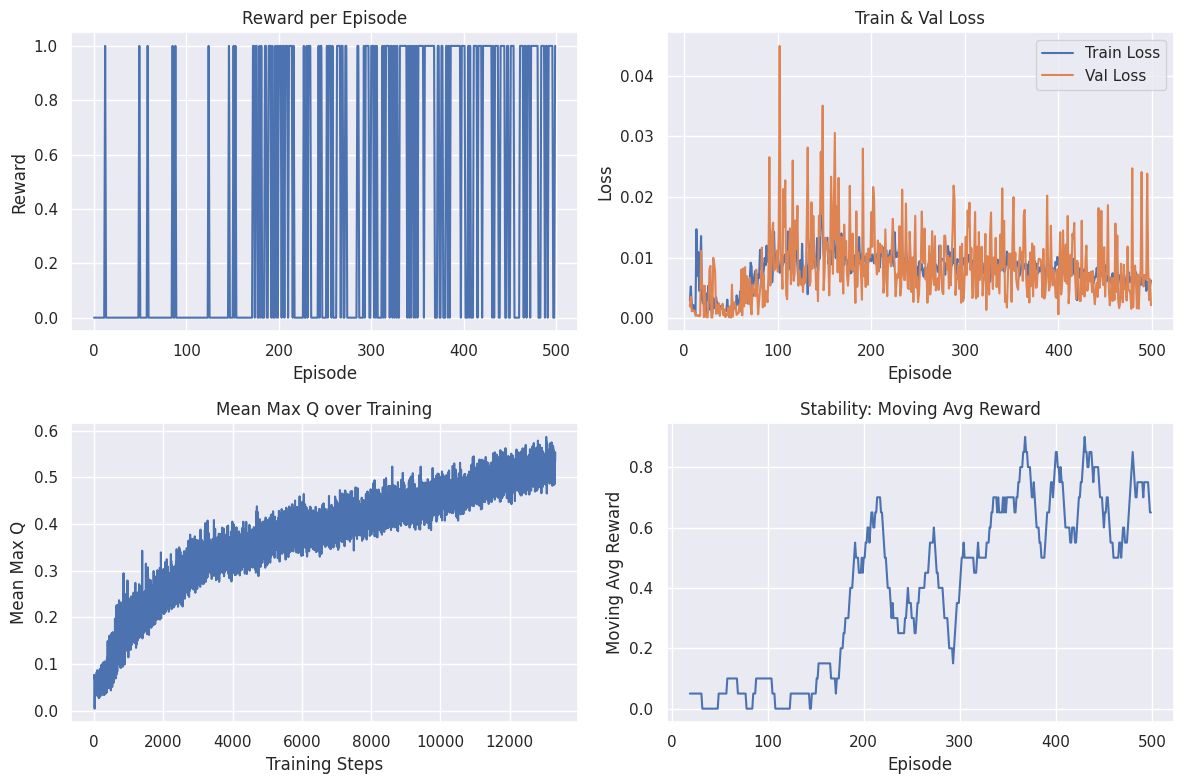

In [ ]:
if __name__ == '__main__':
# Set up FrozenLake with discrete states converted to one-hot encoding
    base_env = gym.make("FrozenLake-v1", render_mode="rgb_array")
    N = base_env.observation_space.n

    # define the new observation_space: a Box of length N
    obs_space = gym.spaces.Box(
        low=0.0,
        high=1.0,
        shape=(N,),
        dtype=np.float32
    )

    # wrap with proper observation_space kwarg
    env = gym.wrappers.TransformObservation(
        base_env,
        lambda s: np.eye(N, dtype=np.float32)[s],
        observation_space=obs_space
    )

    # Dimensions
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    # Agent
    agent = DoubleDQNAgent(state_dim, action_dim,
                           buffer_capacity=10000, batch_size=32,
                           gamma=0.99, lr=1e-3, tau=1e-2,
                           epsilon_start=1.0, epsilon_end=0.01, epsilon_decay=500)

    # Train
    episodes = 500
    rewards, train_losses, val_losses, maxqs = train(agent, env, num_episodes=episodes)

    max_per_episode = 1  # max reward per episode for FrozenLake

    # Quantitative Metrics
    auc_reward = np.trapz(rewards)
    mean_reward = np.mean(rewards)
    std_reward = np.std(rewards)
    cv_reward = std_reward / mean_reward if mean_reward != 0 else float('inf')
    mean_maxq = np.mean(maxqs)

    sample_efficiency_pct = (auc_reward / (max_per_episode * episodes)) * 100

    print(f"Sample Efficiency (AUC normalized): {sample_efficiency_pct:.2f}%")
    print(f"Average Reward: {mean_reward:.2f}, Std: {std_reward:.2f}, CV: {cv_reward:.2f}")
    print(f"Mean Max Q-value: {mean_maxq:.2f}")

    # Track losses over epochs
    df_losses = pd.DataFrame({
        'Episode': np.arange(1, episodes+1),
        'Train Loss': train_losses,
        'Val Loss': val_losses
    })
    df_losses.to_csv('losses_over_epochs.csv', index=False)
    print("\nTrain/Val Losses Over Epochs:")
    print(df_losses.head())
    print(df_losses.tail())

    # Plot all metrics in a 2x2 grid
    fig, axs = plt.subplots(2, 2, figsize=(12, 8))

    axs[0, 0].plot(rewards)
    axs[0, 0].set_title('Reward per Episode')
    axs[0, 0].set_xlabel('Episode')
    axs[0, 0].set_ylabel('Reward')

    axs[0, 1].plot(train_losses, label='Train Loss')
    axs[0, 1].plot(val_losses, label='Val Loss')
    axs[0, 1].set_title('Train & Val Loss')
    axs[0, 1].set_xlabel('Episode')
    axs[0, 1].set_ylabel('Loss')
    axs[0, 1].legend()

    axs[1, 0].plot(maxqs)
    axs[1, 0].set_title('Mean Max Q over Training')
    axs[1, 0].set_xlabel('Training Steps')
    axs[1, 0].set_ylabel('Mean Max Q')

    window = 20
    if len(rewards) >= window:
        mov_avg = np.convolve(rewards, np.ones(window)/window, mode='valid')
        axs[1, 1].plot(range(window-1, episodes), mov_avg)
    axs[1, 1].set_title('Stability: Moving Avg Reward')
    axs[1, 1].set_xlabel('Episode')
    axs[1, 1].set_ylabel('Moving Avg Reward')

    fig.tight_layout()
    plt.show()

    # Evaluation Video
    eval_frames = []
    obs, _ = env.reset()
    done = False
    while not done:
        action = agent.select_action(obs)
        obs, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        frame = env.render()
        eval_frames.append(frame)

    env.close()

    os.makedirs("video_ddqn_fl", exist_ok=True)
    clip = ImageSequenceClip(eval_frames, fps=3)  # 3 fps for clearer steps
    video_path = "video_ddqn_fl/frozenlake_ddqn_eval.mp4"
    clip.write_videofile(video_path, codec="libx264", verbose=False, logger=None)

    video_data = open(video_path, "rb").read()
    b64 = base64.b64encode(video_data).decode('ascii')
    display(HTML(f"""
    <video width=480 controls>
      <source src="data:video/mp4;base64,{b64}" type="video/mp4">
    </video>
    """))

## 1. Neural Network Architecture

All three agents share the same Q-network “skeleton”:

* **Input layer** size = dimensionality of observation/state

  * CartPole-v1: 4
  * LunarLander-v3: 8
  * FrozenLake-v1 (one-hot): 16
* **Hidden layers**: two × 128 units + ReLU
* **Output layer** size = number of discrete actions in each environment

---

## 2. Experience Replay Buffer

* **Capacity**

  * CartPole & LunarLander: 50 000
  * FrozenLake: 10 000
* **Batch size**

  * CartPole & LunarLander: 64
  * FrozenLake: 32
* **Sampling**: uniform random
* **Rationale**: large enough to capture diverse transitions, small enough to fit in memory; batch sizes balance gradient noise vs. compute.

---

## 3. Exploration–Exploitation (ε-Greedy)

At each step:

$$
\varepsilon_t = \varepsilon_{\text{end}} + (\varepsilon_{\text{start}} - \varepsilon_{\text{end}}) \exp\bigl(-t / \varepsilon_{\text{decay}}\bigr)
$$

* **ε\_start** = 1.0 → **ε\_end** = 0.01
* **Decay schedule**

  * CartPole & LunarLander: 10 000 steps
  * FrozenLake: 500 steps
* **Action selection**:

  * With probability ε\_t: random action
  * Else: greedy action $\arg\max_a Q(s,a)$
* **Rationale**: encourage broad early exploration then gradually shift to exploitation for stable learning.

---

## 4. Hyperparameters & Rationale

| Hyperparameter     | CartPole / LunarLander | FrozenLake | Rationale                                                              |
| ------------------ | ---------------------- | ---------- | ---------------------------------------------------------------------- |
| γ (discount)       | 0.99                   | 0.99       | Standard value to capture future rewards without divergence            |
| Learning rate (lr) | 1e-3                   | 1e-3       | Common “sweet spot” for Adam in DQN settings                           |
| Soft-update τ      | 1e-3                   | 1e-2       | Faster τ in FrozenLake to propagate sparse rewards more quickly        |
| Batch size         | 64                     | 32         | Trade-off: gradient variance vs. GPU throughput                        |
| Buffer capacity    | 50 000                 | 10 000     | Enough coverage of state-action space; smaller for discrete/sparse env |

---

## 5. Environment-Specific Trends

### 5.1 CartPole-v1

* **Episodes**: 500
* **Max reward per episode**: 200
* **Sample Efficiency** (AUC normalized): \~37.96%
* **Average Reward**: 76.1 ± 80.2 (CV = 1.05)
* **Mean Max Q-value**: 16.3
* **Convergence**:

  * Rapid reward increase starting \~episode 100
  * Plateau around 150–200 by \~episode 300
  * Stable oscillation thereafter
* **Over-estimation Bias**: moderate (max Q \~16)
* **Stability**: good once reward >150; occasional target-network spikes

### 5.2 LunarLander-v3

* **Episodes**: 500
* **Max reward per episode**: 300
* **Sample Efficiency**: \~3.02%
* **Average Reward**: 9.2 ± 176.4 (CV = 19.2)
* **Mean Max Q-value**: 19.9
* **Convergence**:

  * Non-monotonic: dips and spikes
  * Slow steady climb after \~200 eps
  * Near-solving (\~265) by episode 500
* **Over-estimation Bias**: higher (max Q \~20)
* **Stability**: highly unstable; large reward swings and loss variance

### 5.3 FrozenLake-v1

* **Episodes**: 500
* **Sample Efficiency**: 39.50%
* **Average Reward**: 0.40 ± 0.49 (CV = 1.24)
* **Mean Max Q-value**: 0.37
* **Convergence**: very slow; first solved episodes around 400
* **Over-estimation Bias**: low (max Q \~0.4) but still noisy due to sparse rewards
* **Stability**: high variance in reward and loss

---

## 6. Cross-Environment Comparison

| Metric                   | CartPole-v1    | LunarLander-v3  | FrozenLake-v1      |
| ------------------------ | -------------- | --------------- | ------------------ |
| **Sample Efficiency**    | \~38% (high)   | \~3% (very low) | \~39.5% (moderate) |
| **Average Reward**       | 76.1 ± 80.2    | 9.2 ± 176.4     | 0.40 ± 0.49        |
| **Reward CV**            | 1.05           | 19.2            | 1.24               |
| **Mean Max Q-value**     | 16.3           | 19.9            | 0.37               |
| **Convergence Speed**    | \~300 episodes | \~500 episodes  | >500 episodes      |
| **Stability**            | Good           | Poor            | Poor               |
| **Over-estimation Bias** | Moderate       | High            | Low                |

---

### Takeaways & Next Steps

* **Network capacity**: 128 units suffice for CartPole but may be underpowered for LunarLander’s complex dynamics; consider deeper/wider nets.
* **Replay strategy**: consider prioritized replay in sparse-reward tasks (FrozenLake) to focus on rare successes.
* **Exploration schedule**: accelerate ε-decay or switch to Boltzmann/UCB exploration in FrozenLake.
* **Target updates (τ)**: increase τ for faster propagation in challenging environments.
* **Hyperparameter tuning**: environment-specific sweeps on lr, γ, and hidden sizes to balance stability vs. speed.